In [2]:
!python generate_data.py

Saving to: data/Wave
Total sampled parameters:  200
Training parameters:  160
Single sample run: 
Parametric wave equation finite element model
  Spatial domain (2D): [0, 6.2832] x [0, 6.2832]
  Discretization size: 2160
Run for all parameters:
no more timer available (lff_from_py), reusing last one
Saving files done!


In [3]:
!python tucker.py

Saving to: data/Wave
Loading data
X.shape=(2160, 1002, 160)
Tucker
reconstruction error=0.041485333512096954, variation=3.1136899298483955e-07.
converged in 2 iterations.
Tucker
reconstruction error=0.009190703515374092, variation=4.602299246564412e-09.
converged in 2 iterations.
SVD
Saving SVD


In [1]:
import os
import numpy as np

os.chdir("../..")
savedir = "data/Wave"

In [ ]:
import scipy.sparse as sp
from tensorly.tucker_tensor import TuckerTensor
from src.Wave.ROM import *
from src.Wave.FOM import WaveFEM2D
from src.Utils.utils import *
from src.Bases.rbf import RBFWeights
from src.Bases.lidw import lidw
import matplotlib.pyplot as plt

In [3]:
t = np.linspace(0, 8*np.pi, 501)
fom = WaveFEM2D(L=2*np.pi, h=0.5, orderW=2, orderV=2, width=0.5)
M_Q = fom.MW
print(fom)

Parametric wave equation finite element model
  Spatial domain (2D): [0, 6.2832] x [0, 6.2832]
  Discretization size: 2160


In [4]:
with np.load(os.path.join(savedir, "params_train.npz")) as z:
    params_train = z["params"]
with np.load(os.path.join(savedir, "params_test.npz")) as z:
    params_test = z["params"]

with np.load(os.path.join(savedir, "wave_train.npz")) as z:
    snapshots_Q_train = z["Q"]
    snapshots_P_train = z["P"]

with np.load(os.path.join(savedir, "wave_test.npz")) as z:
    snapshots_Q_test = z["Q"]
    snapshots_P_test = z["P"]

snapshots_Q_train.shape, snapshots_Q_test.shape, params_train.shape, params_test.shape

((160, 2160, 501), (40, 2160, 501), (160, 3), (40, 3))

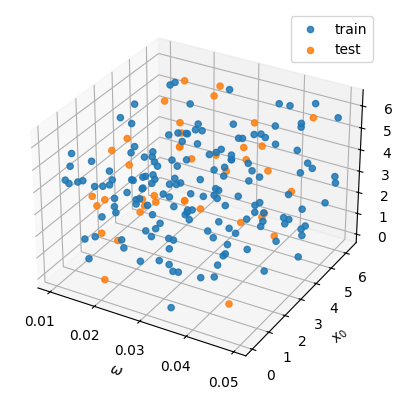

In [5]:
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(params_train[:,0], params_train[:,1], params_train[:,2],
           c="tab:blue", s=20, alpha=0.85, label="train")
ax.scatter(params_test[:,0],  params_test[:,1],  params_test[:,2],
           c="tab:orange", s=20, alpha=0.85, label="test")
ax.set_xlabel(r"$\omega$"); ax.set_ylabel("$x_0$"); ax.set_zlabel("$y_0$")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
data = np.load(os.path.join(savedir, "svd_rank120_Mortho.npz"))
U_mono, S_mono = data["U"], data["S"]
print("Check for MW-orthonormality: ||U^T MW U - I|| =",
      np.linalg.norm(U_mono.T @ M_Q @ U_mono - np.eye(U_mono.shape[1])))

Check for MW-orthonormality: ||U^T MW U - I|| = 2.154868503913797e-14


In [7]:
core, factors = load_tucker_npz(os.path.join(savedir, "tucker_60x60x60_Mortho.npz"))
tucker_tensor = TuckerTensor((core, factors))
print("Tucker shape:", tucker_tensor.shape)

Tucker shape: (2160, 1002, 160)


In [8]:
r_arr = np.array([1, 5, 10, 20, 40, 60], dtype=int)

In [9]:
rbfw = RBFWeights(
    mus=params_train,
    basis="gaussian",
    eps=1,
    order=-1,
    nugget=0,
)

## Single run

In [10]:
idx       = 10
r_idx_rbf = 2
r_idx_lid = 2
r_idx_mono = 4

mu = params_test[idx]   # [omega, x0, y0]
print(f"mu = omega={mu[0]:.3f}, x0={mu[1]:.3f}, y0={mu[2]:.3f}")

mu = omega=0.014, x0=2.190, y0=4.650


In [11]:
W_rbf = rbfw.weights(params_test[idx])
U_rbf, s_rbf, _ = buildParBasis(tucker_tensor, W_rbf)

print("MW-orthonormality: ||U^T MW U - I|| =",
      np.linalg.norm(U_rbf.T @ M_Q @ U_rbf - np.eye(U_rbf.shape[1])))
print("Projection error  :", projection_error_M(snapshots_Q_test[idx],
      U_rbf[:, :r_arr[r_idx_rbf]], M_Q, Mnorm))

ROM_rbf = WavePODROM(fom, U_rbf[:, :r_arr[r_idx_rbf]])
Qr_rbf, Pr_rbf, Ur_rbf = ROM_rbf.solve(t, mu[0], mu[1], mu[2])
Q_rbf = Ur_rbf @ Qr_rbf

print("ROM error (MW)    :",
      Mnorm(snapshots_Q_test[idx] - Q_rbf, M_Q) / Mnorm(snapshots_Q_test[idx], M_Q))

MW-orthonormality: ||U^T MW U - I|| = 1.798320809265837e-14
Projection error  : 0.04603840028086618
ROM error (MW)    : 0.05740033737866018


In [12]:
ROM_mono = WavePODROM(fom, U_mono[:, :r_arr[r_idx_mono]])
Qr_mono, Pr_mono, Ur_mono = ROM_mono.solve(t, mu[0], mu[1], mu[2])
Q_mono = Ur_mono @ Qr_mono

print("Projection error  :", projection_error_M(snapshots_Q_test[idx],
      Ur_mono, M_Q, Mnorm))
print("ROM error (MW)    :",
      Mnorm(snapshots_Q_test[idx] - Q_mono, M_Q) / Mnorm(snapshots_Q_test[idx], M_Q))

Projection error  : 0.03914733410613102
ROM error (MW)    : 0.04189677048354769


In [13]:
W_lid = lidw(params_train, 15, params_test[idx], eps=1e-16, rcond=1e-16)
U_lid, _, _ = buildParBasis(tucker_tensor, W_lid)

print("Projection error  :", projection_error_M(snapshots_Q_test[idx],
      U_lid[:, :r_arr[r_idx_lid]], M_Q, Mnorm))

ROM_lid = WavePODROM(fom, U_lid[:, :r_arr[r_idx_lid]])
Qr_lid, Pr_lid, Ur_lid = ROM_lid.solve(t, mu[0], mu[1], mu[2])
Q_lid = Ur_lid @ Qr_lid

print("ROM error (MW)    :",
      Mnorm(snapshots_Q_test[idx] - Q_lid, M_Q) / Mnorm(snapshots_Q_test[idx], M_Q))

Projection error  : 0.0883766009977635
ROM error (MW)    : 0.08897163021781106


## Multiple runs

In [14]:
def wave_sweep_dataset(fom, params, r_arr, snapshots_Q, t, M_Q,
                       basis_builder, label=""):
    """ROM and projection-error sweep over a dataset.

    Returns
    -------
    rom_Q  : (len(r_arr), n_cases) – relative MW ROM error
    proj_Q : (len(r_arr), n_cases) – relative MW projection error
    """
    r_arr  = np.asarray(r_arr, dtype=int)
    rmax   = int(np.max(r_arr))
    n_cases = params.shape[0]

    rom_Q  = np.zeros((len(r_arr), n_cases))
    proj_Q = np.zeros((len(r_arr), n_cases))

    for idx in range(n_cases):
        mu      = params[idx]
        Q_truth = snapshots_Q[idx]          # (Nx, Nt)
        denom   = Mnorm(Q_truth, M_Q)

        U_max = basis_builder(mu, rmax)
        ROM   = WavePODROM(fom, U_max)

        for r_idx, r in enumerate(r_arr):
            Qr, Pr, Ur = ROM.solve(t, mu[0], mu[1], mu[2], r=int(r))
            Q_full = Ur @ Qr
            rom_Q [r_idx, idx] = Mnorm(Q_truth - Q_full, M_Q) / denom
            proj_Q[r_idx, idx] = projection_error_M(Q_truth, Ur, M_Q, Mnorm)

        if label:
            print(f"{label}: {idx+1}/{n_cases}", end="\r")
    print()
    return rom_Q, proj_Q


# Basis builders (return (Nx, rmax) basis for a given mu)
def build_mono(mu, rmax):
    return U_mono[:, :rmax]

def build_rbf(mu, rmax):
    W = rbfw.weights(mu)
    U, _, _ = buildParBasis(tucker_tensor, W)
    return U[:, :rmax]

def build_lid(mu, rmax, k=15, eps=1e-16, rcond=1e-16):
    W = lidw(params_train, k, mu, eps=eps, rcond=rcond)
    U, _, _ = buildParBasis(tucker_tensor, W)
    return U[:, :rmax]

### Test

In [15]:
mono_rom_te, mono_proj_te = wave_sweep_dataset(
    fom, params_test, r_arr, snapshots_Q_test, t, M_Q, build_mono, label="mono test")

rbf_rom_te, rbf_proj_te = wave_sweep_dataset(
    fom, params_test, r_arr, snapshots_Q_test, t, M_Q, build_rbf, label="rbf test")

lid_rom_te, lid_proj_te = wave_sweep_dataset(
    fom, params_test, r_arr, snapshots_Q_test, t, M_Q, build_lid, label="lid test")

mono test: 40/40
rbf test: 40/40
lid test: 40/40


### Train

In [16]:
mono_rom_tr, mono_proj_tr = wave_sweep_dataset(
    fom, params_train, r_arr, snapshots_Q_train, t, M_Q, build_mono, label="mono train")

rbf_rom_tr, rbf_proj_tr = wave_sweep_dataset(
    fom, params_train, r_arr, snapshots_Q_train, t, M_Q, build_rbf, label="rbf train")

lid_rom_tr, lid_proj_tr = wave_sweep_dataset(
    fom, params_train, r_arr, snapshots_Q_train, t, M_Q, build_lid, label="lid train")

mono train: 160/160
rbf train: 160/160
lid train: 160/160


### Save

In [17]:
np.savez(
    os.path.join(savedir, "errors_60x60x60.npz"),
    r_arr=r_arr,
    params_train=params_train,
    params_test=params_test,

    mono_rom_train=mono_rom_tr,  mono_proj_train=mono_proj_tr,
    mono_rom_test=mono_rom_te,   mono_proj_test=mono_proj_te,

    rbf_rom_train=rbf_rom_tr,    rbf_proj_train=rbf_proj_tr,
    rbf_rom_test=rbf_rom_te,     rbf_proj_test=rbf_proj_te,

    lid_rom_train=lid_rom_tr,    lid_proj_train=lid_proj_tr,
    lid_rom_test=lid_rom_te,     lid_proj_test=lid_proj_te,
)